In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style settings
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'
sns.set_palette('tab10')

# Load data
df = pd.read_csv('master_urban_livability_5cities.csv')
print("Dataset shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())
print("\nPreview:")
df.head(10)

Dataset shape: (50, 9)

Missing values:
city                  0
year                  0
LST_Celsius           0
NDVI                  0
image_count           0
AQI_mean              5
AQI_days_with_data    5
population            0
growth_rate_pct       0
dtype: int64

Preview:


,city,year,LST_Celsius,NDVI,image_count,AQI_mean,AQI_days_with_data,population,growth_rate_pct
0,Hyderabad,2015.0,36.64,0.1490,15,143.42,272.0,8866776,3.42
1,Hyderabad,2016.0,39.15,0.1366,12,124.24,337.0,9170459,3.42
2,Hyderabad,2017.0,37.02,0.1443,15,112.33,358.0,9484544,3.42
3,Hyderabad,2018.0,37.43,0.1461,16,97.56,365.0,9809385,3.42
4,Hyderabad,2019.0,36.20,0.1413,12,93.98,365.0,10145352,3.42
5,Hyderabad,2020.0,34.41,0.1601,13,78.17,183.0,10492826,3.42
6,Hyderabad,2021.0,38.49,0.1498,11,87.93,365.0,10852201,3.42
7,Hyderabad,2022.0,36.55,0.1407,12,87.86,365.0,11223884,3.42
8,Hyderabad,2023.0,37.53,0.1488,13,84.29,365.0,11608298,3.42
9,Hyderabad,2024.0,35.68,0.1447,13,NaN,NaN,12005877,3.42


LST trend analysis

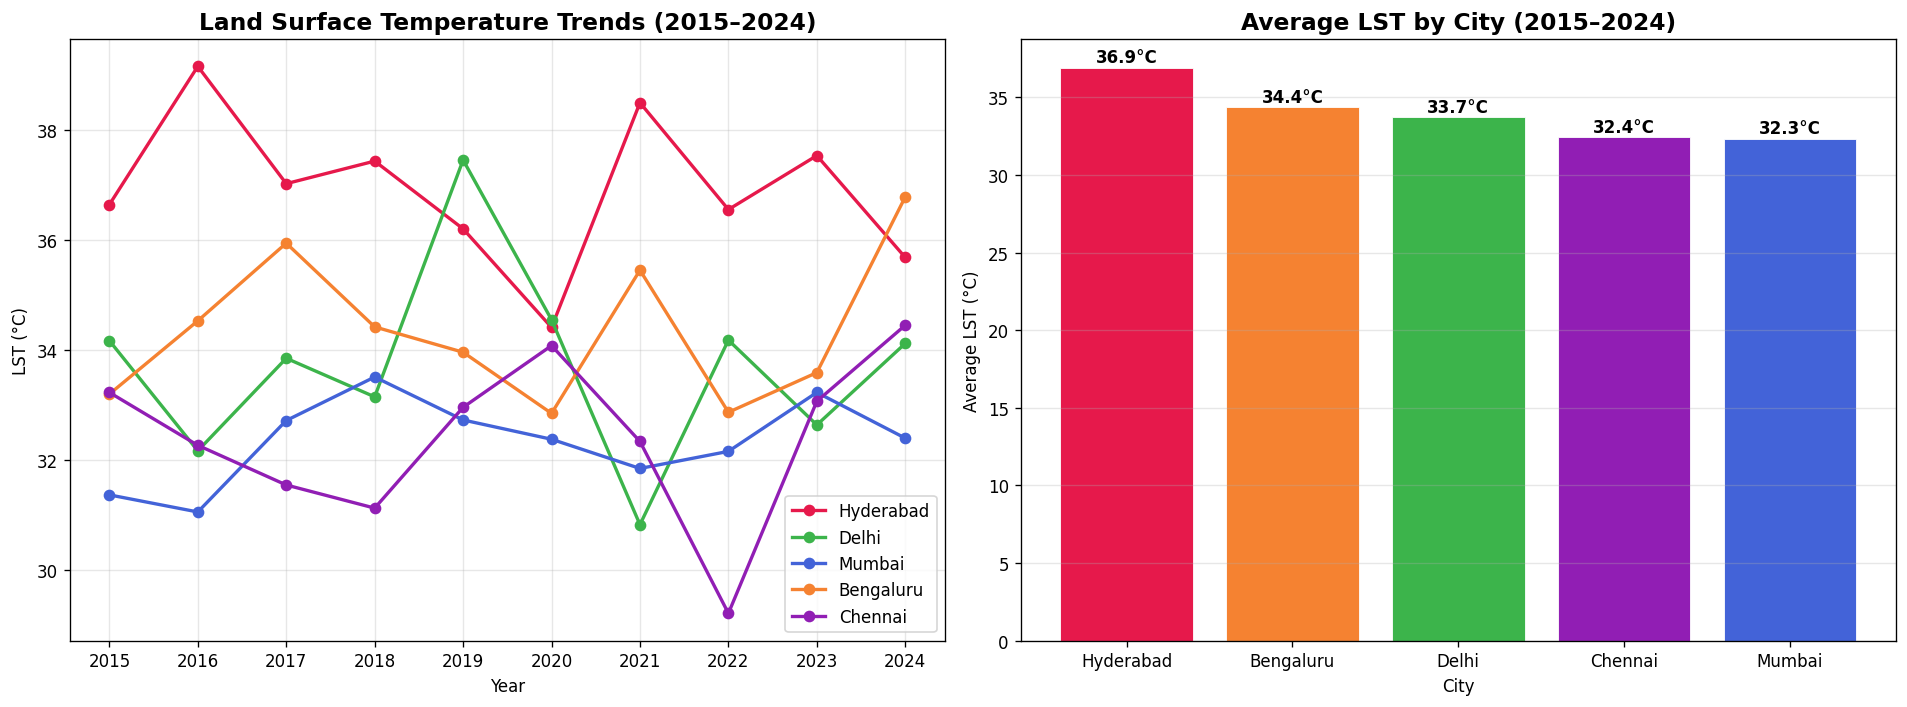


Average LST by City (2015-2024):
city
Hyderabad    36.91
Bengaluru    34.36
Delhi        33.71
Chennai      32.43
Mumbai       32.34
Name: LST_Celsius, dtype: float64

LST Change (2015 vs 2024):
  Hyderabad: -0.96°C
  Delhi: -0.05°C
  Mumbai: +1.03°C
  Bengaluru: +3.58°C
  Chennai: +1.22°C


In [ ]:

cities = ['Hyderabad', 'Delhi', 'Mumbai', 'Bengaluru', 'Chennai']
colors = {'Hyderabad': '#e6194b', 'Delhi': '#3cb44b',
          'Mumbai': '#4363d8', 'Bengaluru': '#f58231', 'Chennai': '#911eb4'}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: LST trend lines per city
ax1 = axes[0]
for city in cities:
    city_df = df[df['city'] == city]
    ax1.plot(city_df['year'], city_df['LST_Celsius'],
             marker='o', linewidth=2, label=city, color=colors[city])

ax1.set_title('Land Surface Temperature Trends (2015–2024)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Year')
ax1.set_ylabel('LST (°C)')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.xaxis.set_major_locator(ticker.MultipleLocator(1))

# Plot 2: Average LST per city (bar chart for comparison)
ax2 = axes[1]
avg_lst = df.groupby('city')['LST_Celsius'].mean().sort_values(ascending=False)
bars = ax2.bar(avg_lst.index, avg_lst.values,
               color=[colors[c] for c in avg_lst.index], edgecolor='white', linewidth=0.5)
ax2.set_title('Average LST by City (2015–2024)', fontsize=14, fontweight='bold')
ax2.set_xlabel('City')
ax2.set_ylabel('Average LST (°C)')
ax2.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, val in zip(bars, avg_lst.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{val:.1f}°C', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('lst_trends.png', bbox_inches='tight', dpi=150)
plt.show()

print("\nAverage LST by City (2015-2024):")
print(avg_lst.round(2))

# Which city heated up the most (difference between first and last year)
print("\nLST Change (2015 vs 2024):")
for city in cities:
    city_df = df[df['city'] == city].sort_values('year')
    change = city_df.iloc[-1]['LST_Celsius'] - city_df.iloc[0]['LST_Celsius']
    print(f"  {city}: {change:+.2f}°C")

NDVI analysis

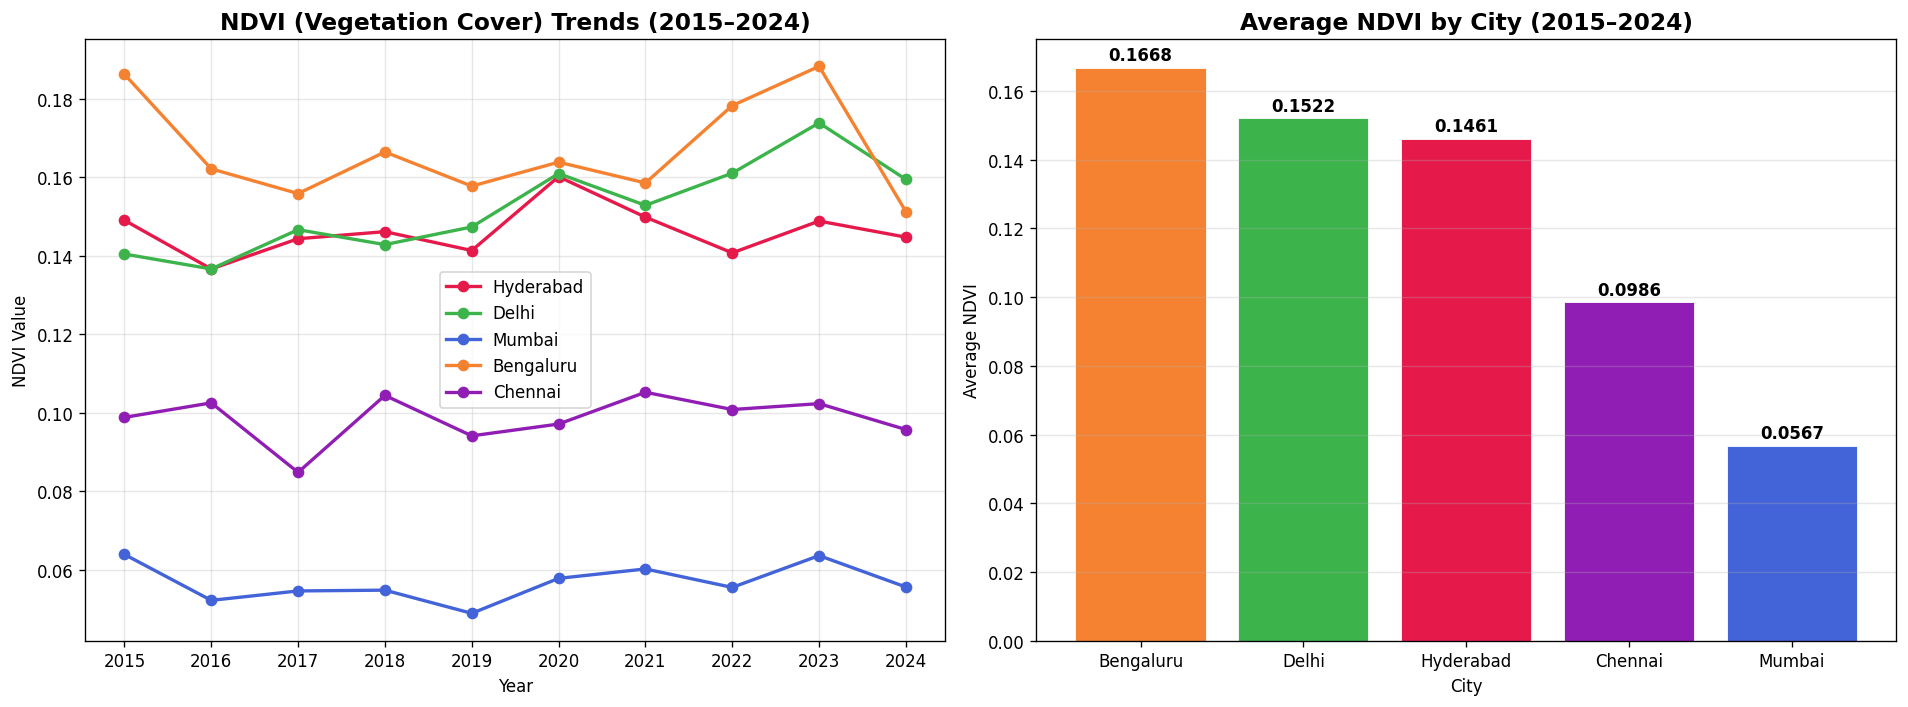


Average NDVI by City (2015-2024):
city
Bengaluru    0.1668
Delhi        0.1522
Hyderabad    0.1461
Chennai      0.0986
Mumbai       0.0567
Name: NDVI, dtype: float64

NDVI Change (2015 vs 2024):
  Hyderabad: -0.0043
  Delhi: +0.0190
  Mumbai: -0.0083
  Bengaluru: -0.0350
  Chennai: -0.0031


In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: NDVI trend lines per city
ax1 = axes[0]
for city in cities:
    city_df = df[df['city'] == city]
    ax1.plot(city_df['year'], city_df['NDVI'],
             marker='o', linewidth=2, label=city, color=colors[city])

ax1.set_title('NDVI (Vegetation Cover) Trends (2015–2024)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Year')
ax1.set_ylabel('NDVI Value')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.xaxis.set_major_locator(ticker.MultipleLocator(1))

# Plot 2: Average NDVI per city
ax2 = axes[1]
avg_ndvi = df.groupby('city')['NDVI'].mean().sort_values(ascending=False)
bars = ax2.bar(avg_ndvi.index, avg_ndvi.values,
               color=[colors[c] for c in avg_ndvi.index], edgecolor='white', linewidth=0.5)
ax2.set_title('Average NDVI by City (2015–2024)', fontsize=14, fontweight='bold')
ax2.set_xlabel('City')
ax2.set_ylabel('Average NDVI')
ax2.grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, avg_ndvi.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{val:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('ndvi_trends.png', bbox_inches='tight', dpi=150)
plt.show()

print("\nAverage NDVI by City (2015-2024):")
print(avg_ndvi.round(4))

print("\nNDVI Change (2015 vs 2024):")
for city in cities:
    city_df = df[df['city'] == city].sort_values('year')
    change = city_df.iloc[-1]['NDVI'] - city_df.iloc[0]['NDVI']
    print(f"  {city}: {change:+.4f}")

AQI trends

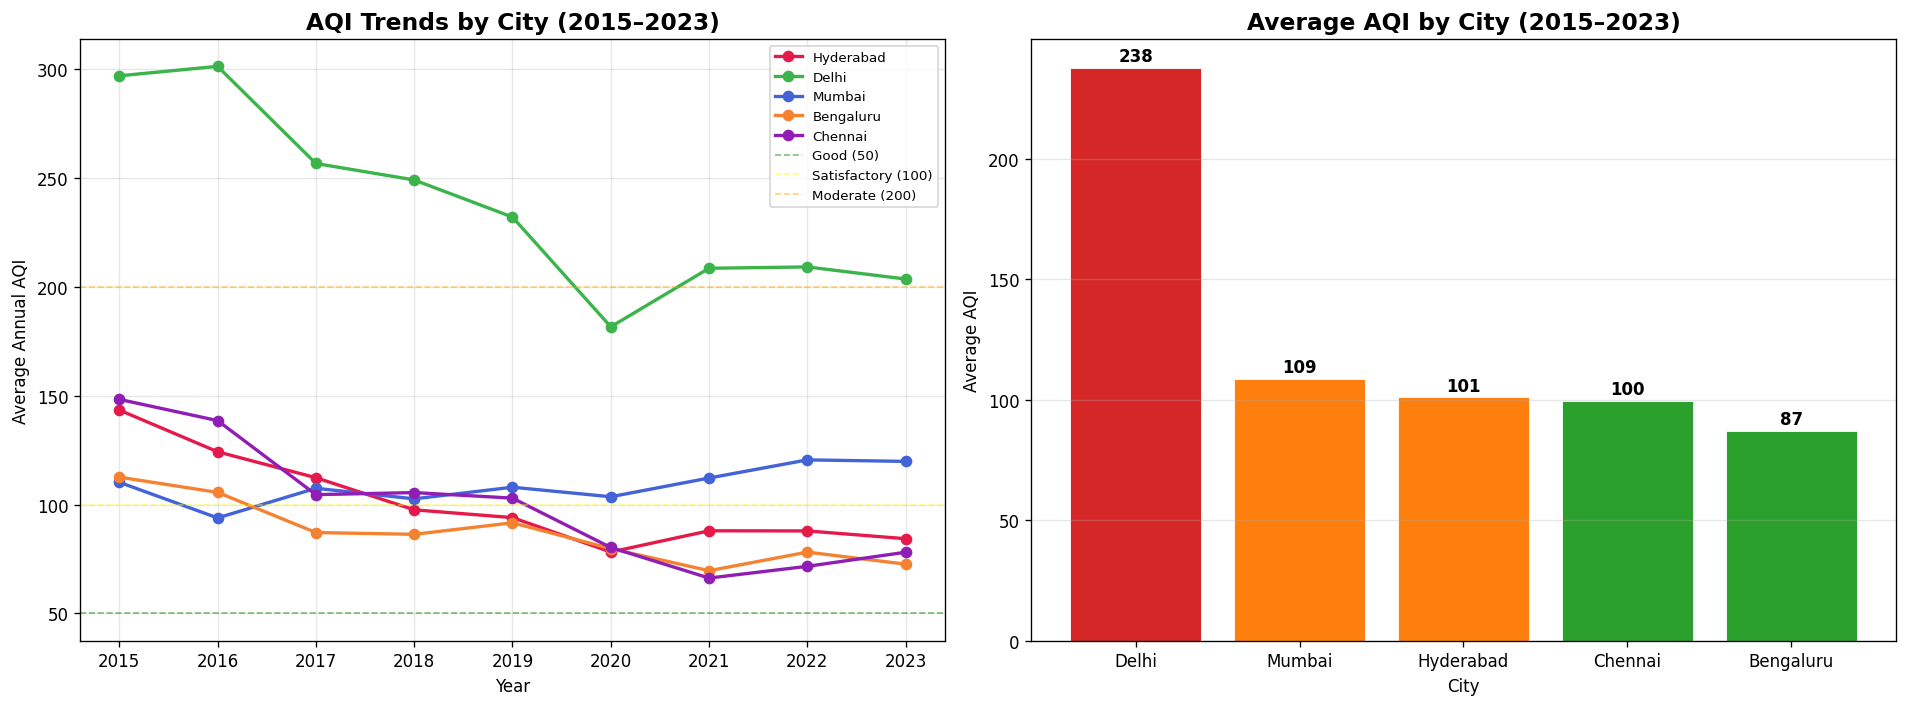


Average AQI by City (2015-2023):
city
Delhi        237.72
Mumbai       108.69
Hyderabad    101.09
Chennai       99.56
Bengaluru     87.02
Name: AQI_mean, dtype: float64

AQI Change (first available year vs 2023):
  Hyderabad (2015→2023): -59.13
  Delhi (2015→2023): -93.39
  Mumbai (2015→2023): +9.60
  Bengaluru (2015→2023): -39.98
  Chennai (2015→2023): -70.25


In [ ]:

# Filter to years where AQI data exists
aqi_df = df[df['AQI_mean'].notna()].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: AQI trend lines per city
ax1 = axes[0]
for city in cities:
    city_df = aqi_df[aqi_df['city'] == city].sort_values('year')
    ax1.plot(city_df['year'], city_df['AQI_mean'],
             marker='o', linewidth=2, label=city, color=colors[city])

# Add AQI category reference lines
ax1.axhline(y=50, color='green', linestyle='--', alpha=0.5, linewidth=1, label='Good (50)')
ax1.axhline(y=100, color='yellow', linestyle='--', alpha=0.5, linewidth=1, label='Satisfactory (100)')
ax1.axhline(y=200, color='orange', linestyle='--', alpha=0.5, linewidth=1, label='Moderate (200)')

ax1.set_title('AQI Trends by City (2015–2023)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Year')
ax1.set_ylabel('Average Annual AQI')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)
ax1.xaxis.set_major_locator(ticker.MultipleLocator(1))

# Plot 2: Average AQI per city
ax2 = axes[1]
avg_aqi = aqi_df.groupby('city')['AQI_mean'].mean().sort_values(ascending=False)
bar_colors = []
for val in avg_aqi.values:
    if val > 200: bar_colors.append('#d62728')
    elif val > 100: bar_colors.append('#ff7f0e')
    else: bar_colors.append('#2ca02c')

bars = ax2.bar(avg_aqi.index, avg_aqi.values,
               color=bar_colors, edgecolor='white', linewidth=0.5)
ax2.set_title('Average AQI by City (2015–2023)', fontsize=14, fontweight='bold')
ax2.set_xlabel('City')
ax2.set_ylabel('Average AQI')
ax2.grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, avg_aqi.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val:.0f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('aqi_trends.png', bbox_inches='tight', dpi=150)
plt.show()

print("\nAverage AQI by City (2015-2023):")
print(avg_aqi.round(2))

print("\nAQI Change (first available year vs 2023):")
for city in cities:
    city_df = aqi_df[aqi_df['city'] == city].sort_values('year')
    first_year = city_df.iloc[0]['year']
    change = city_df.iloc[-1]['AQI_mean'] - city_df.iloc[0]['AQI_mean']
    print(f"  {city} ({int(first_year)}→2023): {change:+.2f}")

 correlation analysis

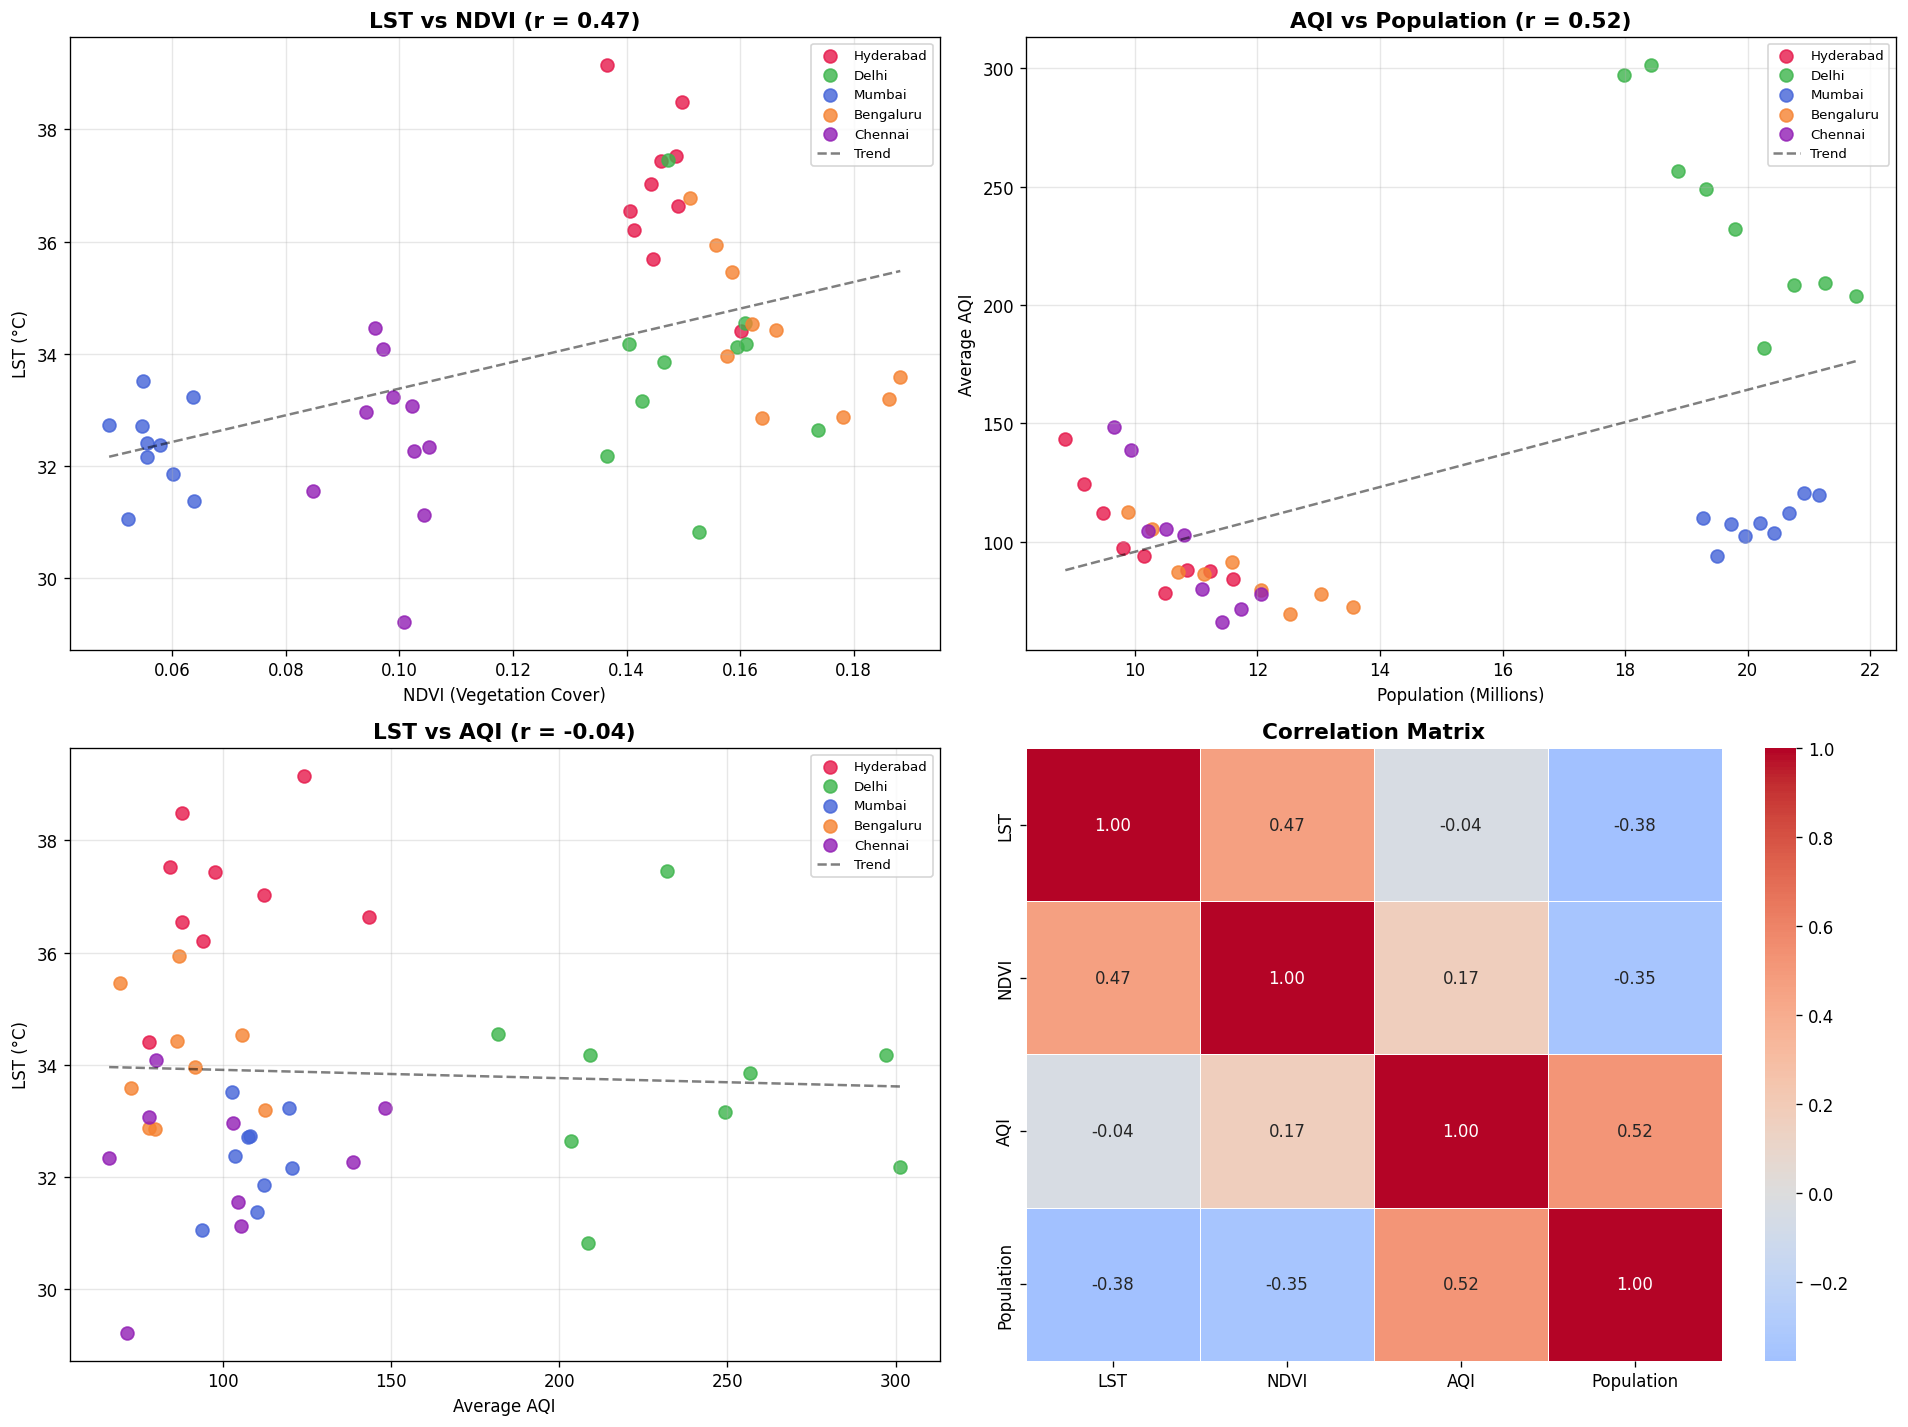


Correlation Summary:
  LST vs NDVI:       r = 0.466
  AQI vs Population: r = 0.516
  LST vs AQI:        r = -0.041


In [ ]:

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: LST vs NDVI (does less green = more heat?)
ax1 = axes[0, 0]
for city in cities:
    city_df = df[df['city'] == city]
    ax1.scatter(city_df['NDVI'], city_df['LST_Celsius'],
                label=city, color=colors[city], s=60, alpha=0.8)

# Add trend line
from numpy.polynomial.polynomial import polyfit
x = df['NDVI'].values
y = df['LST_Celsius'].values
b, m = polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 100)
ax1.plot(x_line, m*x_line + b, 'k--', alpha=0.5, linewidth=1.5, label='Trend')
corr1 = df['NDVI'].corr(df['LST_Celsius'])
ax1.set_title(f'LST vs NDVI (r = {corr1:.2f})', fontsize=13, fontweight='bold')
ax1.set_xlabel('NDVI (Vegetation Cover)')
ax1.set_ylabel('LST (°C)')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# Plot 2: AQI vs Population
ax2 = axes[0, 1]
aqi_df = df[df['AQI_mean'].notna()]
for city in cities:
    city_df = aqi_df[aqi_df['city'] == city]
    ax2.scatter(city_df['population']/1e6, city_df['AQI_mean'],
                label=city, color=colors[city], s=60, alpha=0.8)

x2 = aqi_df['population'].values/1e6
y2 = aqi_df['AQI_mean'].values
b2, m2 = polyfit(x2, y2, 1)
x_line2 = np.linspace(x2.min(), x2.max(), 100)
ax2.plot(x_line2, m2*x_line2 + b2, 'k--', alpha=0.5, linewidth=1.5, label='Trend')
corr2 = aqi_df['population'].corr(aqi_df['AQI_mean'])
ax2.set_title(f'AQI vs Population (r = {corr2:.2f})', fontsize=13, fontweight='bold')
ax2.set_xlabel('Population (Millions)')
ax2.set_ylabel('Average AQI')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

# Plot 3: LST vs AQI
ax3 = axes[1, 0]
for city in cities:
    city_df = aqi_df[aqi_df['city'] == city]
    ax3.scatter(city_df['AQI_mean'], city_df['LST_Celsius'],
                label=city, color=colors[city], s=60, alpha=0.8)

x3 = aqi_df['AQI_mean'].values
y3 = aqi_df['LST_Celsius'].values
b3, m3 = polyfit(x3, y3, 1)
x_line3 = np.linspace(x3.min(), x3.max(), 100)
ax3.plot(x_line3, m3*x_line3 + b3, 'k--', alpha=0.5, linewidth=1.5, label='Trend')
corr3 = aqi_df['AQI_mean'].corr(aqi_df['LST_Celsius'])
ax3.set_title(f'LST vs AQI (r = {corr3:.2f})', fontsize=13, fontweight='bold')
ax3.set_xlabel('Average AQI')
ax3.set_ylabel('LST (°C)')
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)

# Plot 4: Correlation heatmap
ax4 = axes[1, 1]
corr_cols = ['LST_Celsius', 'NDVI', 'AQI_mean', 'population']
corr_matrix = df[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax4, linewidths=0.5,
            xticklabels=['LST', 'NDVI', 'AQI', 'Population'],
            yticklabels=['LST', 'NDVI', 'AQI', 'Population'])
ax4.set_title('Correlation Matrix', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('correlation_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

print("\nCorrelation Summary:")
print(f"  LST vs NDVI:       r = {corr1:.3f}")
print(f"  AQI vs Population: r = {corr2:.3f}")
print(f"  LST vs AQI:        r = {corr3:.3f}")

the livability ranking

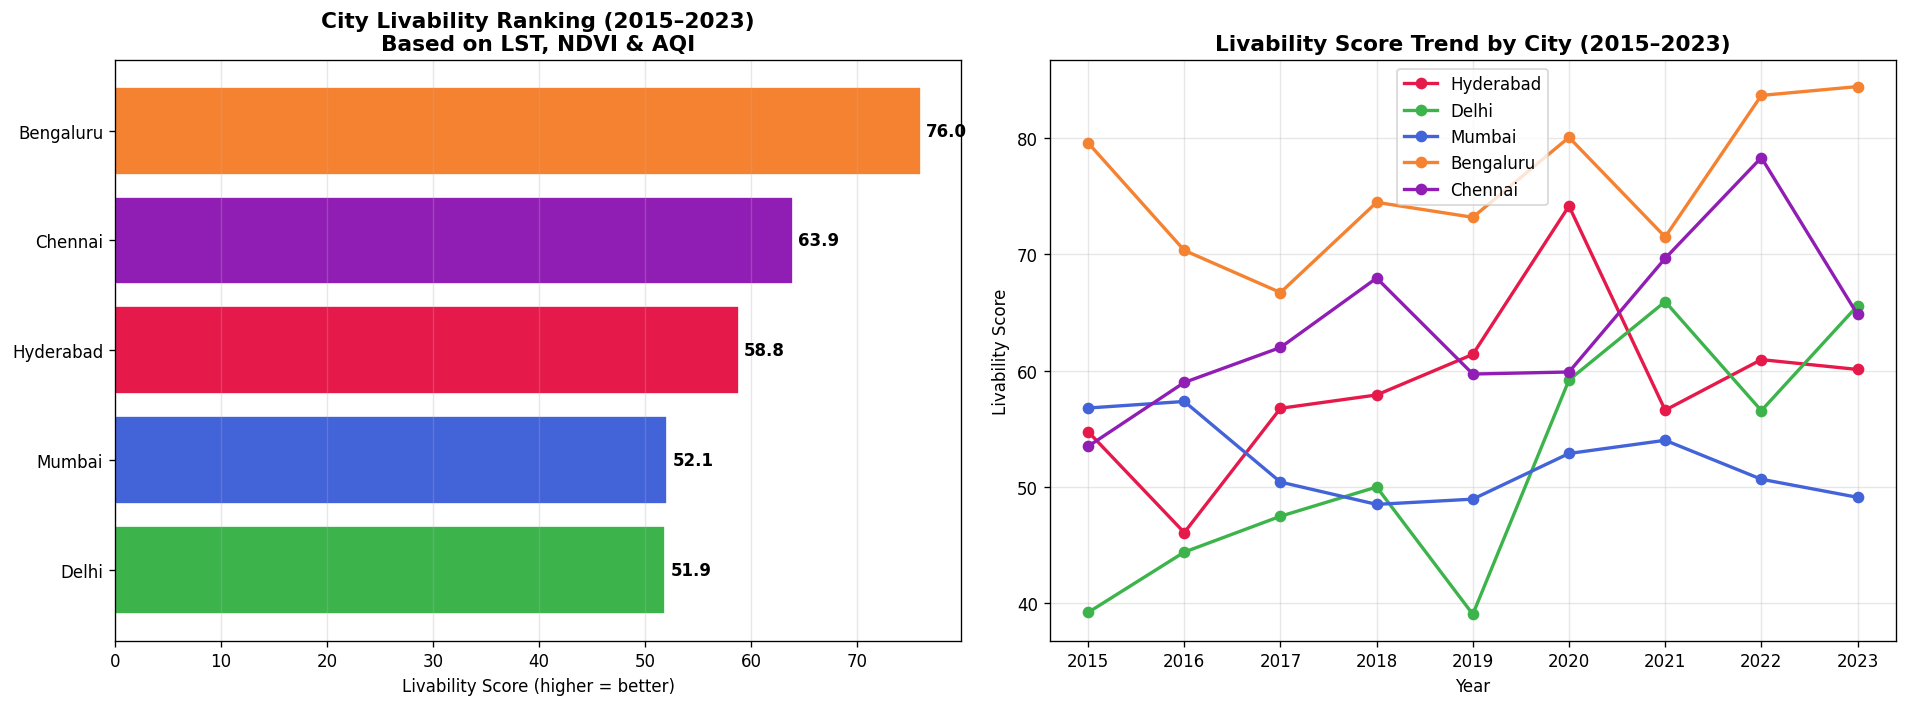


Final City Livability Ranking (2015–2023):
  #1  Bengaluru    Score: 76.0
  #2  Chennai      Score: 63.9
  #3  Hyderabad    Score: 58.8
  #4  Mumbai       Score: 52.1
  #5  Delhi        Score: 51.9

Enriched dataset saved as master_with_scores.csv


In [ ]:


ranking_df = df[df['year'] <= 2023].copy()

def normalize(series, invert=False):
    mn, mx = series.min(), series.max()
    normalized = (series - mn) / (mx - mn)
    return 1 - normalized if invert else normalized

# Compute scores per row
ranking_df['LST_score']  = normalize(ranking_df['LST_Celsius'], invert=True)
ranking_df['NDVI_score'] = normalize(ranking_df['NDVI'], invert=False)

# AQI score only where available
aqi_norm = normalize(ranking_df['AQI_mean'], invert=True)
ranking_df['AQI_score'] = aqi_norm

# Composite livability score (equal weights)
# For rows with AQI: average of 3 scores
# For rows without AQI: average of 2 scores
ranking_df['livability_score'] = ranking_df.apply(
    lambda r: np.nanmean([r['LST_score'], r['NDVI_score'], r['AQI_score']]), axis=1
)

# City-level average livability score
city_ranking = ranking_df.groupby('city')['livability_score'].mean().sort_values(ascending=False).reset_index()
city_ranking.columns = ['city', 'livability_score']
city_ranking['rank'] = range(1, len(city_ranking) + 1)
city_ranking['livability_score'] = (city_ranking['livability_score'] * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Overall livability ranking
ax1 = axes[0]
bar_colors_rank = [colors[c] for c in city_ranking['city']]
bars = ax1.barh(city_ranking['city'][::-1], city_ranking['livability_score'][::-1],
                color=bar_colors_rank[::-1], edgecolor='white')
ax1.set_title('City Livability Ranking (2015–2023)\nBased on LST, NDVI & AQI',
              fontsize=13, fontweight='bold')
ax1.set_xlabel('Livability Score (higher = better)')
ax1.grid(True, alpha=0.3, axis='x')
for bar, val in zip(bars, city_ranking['livability_score'][::-1]):
    ax1.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'{val}', va='center', fontweight='bold')

# Plot 2: Livability score trend over years
ax2 = axes[1]
yearly_rank = ranking_df.groupby(['city', 'year'])['livability_score'].mean().reset_index()
for city in cities:
    city_df = yearly_rank[yearly_rank['city'] == city]
    ax2.plot(city_df['year'], city_df['livability_score'] * 100,
             marker='o', linewidth=2, label=city, color=colors[city])

ax2.set_title('Livability Score Trend by City (2015–2023)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Year')
ax2.set_ylabel('Livability Score')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_locator(ticker.MultipleLocator(1))

plt.tight_layout()
plt.savefig('livability_ranking.png', bbox_inches='tight', dpi=150)
plt.show()

print("\nFinal City Livability Ranking (2015–2023):")
print("="*45)
for _, row in city_ranking.iterrows():
    print(f"  #{int(row['rank'])}  {row['city']:<12} Score: {row['livability_score']}")

# Save enriched dataset with scores
ranking_df.to_csv('master_with_scores.csv', index=False)
print("\nEnriched dataset saved as master_with_scores.csv")

Heat Sensitivity Coefficient

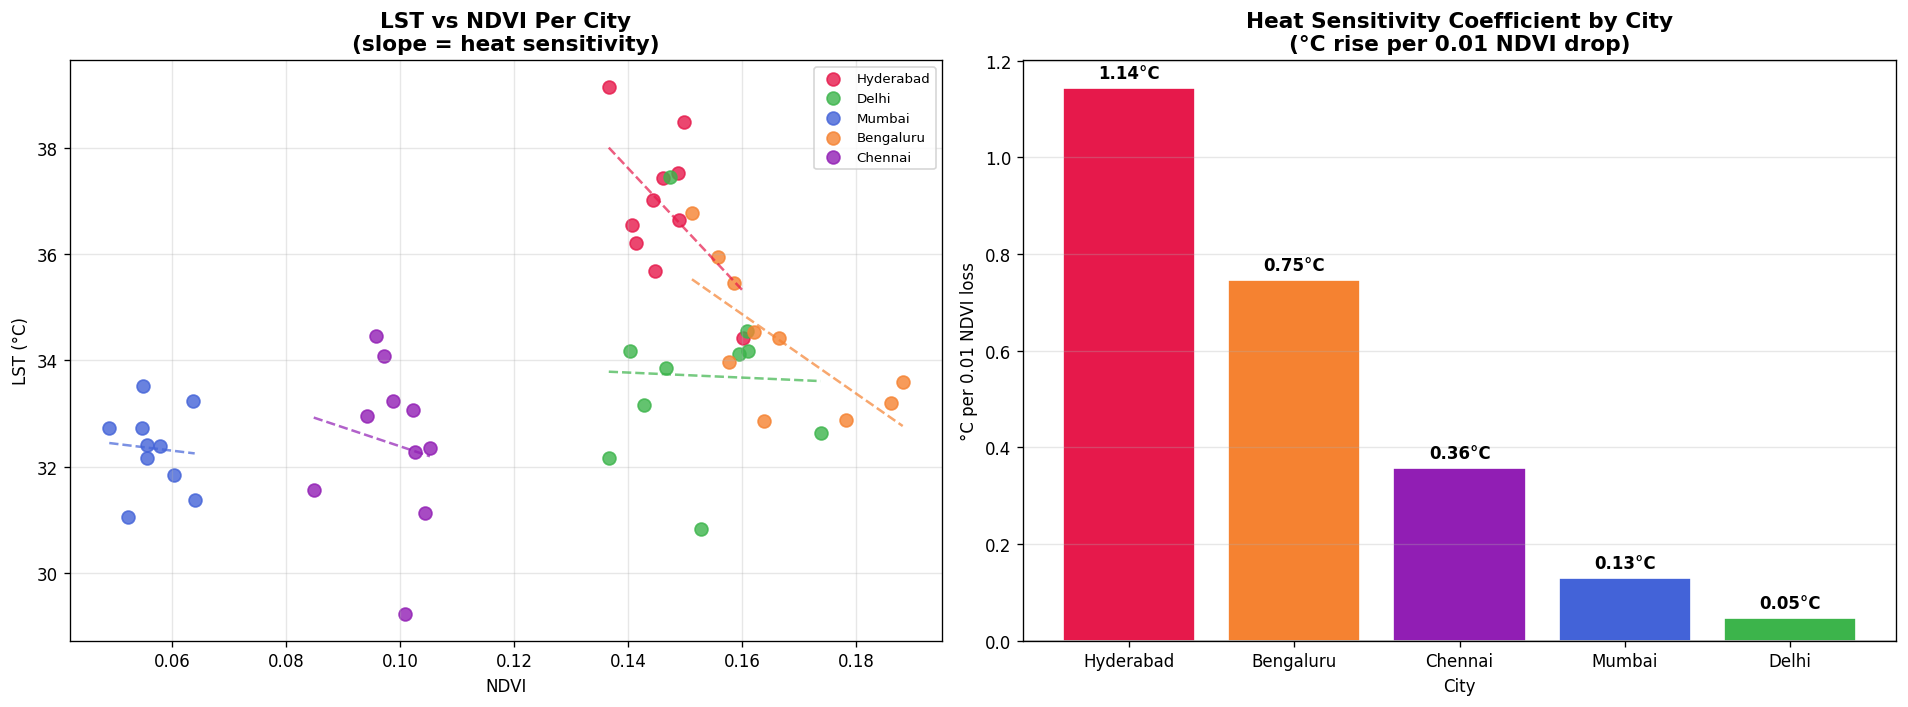


Heat Sensitivity Coefficient (°C rise per 0.01 NDVI drop):
(Positive = city heats up when green cover lost)
(Negative = unusual inverse relationship)

  Hyderabad   : +1.144°C  → heats up
  Bengaluru   : +0.746°C  → heats up
  Chennai     : +0.357°C  → heats up
  Mumbai      : +0.130°C  → heats up
  Delhi       : +0.048°C  → heats up


In [ ]:
from scipy import stats

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax1 = axes[0]
sensitivity = {}

for city in cities:
    city_df = df[df['city'] == city].sort_values('year')

    # Linear regression: NDVI vs LST for this city
    slope, intercept, r, p, se = stats.linregress(city_df['NDVI'], city_df['LST_Celsius'])

    # Sensitivity: degrees C rise per 0.01 drop in NDVI
    sensitivity[city] = -slope * 0.01

    ax1.scatter(city_df['NDVI'], city_df['LST_Celsius'],
                color=colors[city], s=60, alpha=0.8, label=city)

    ndvi_range = np.linspace(city_df['NDVI'].min(), city_df['NDVI'].max(), 50)
    ax1.plot(ndvi_range, slope * ndvi_range + intercept,
             color=colors[city], linewidth=1.5, linestyle='--', alpha=0.7)

ax1.set_title('LST vs NDVI Per City\n(slope = heat sensitivity)',
              fontsize=13, fontweight='bold')
ax1.set_xlabel('NDVI')
ax1.set_ylabel('LST (°C)')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# Plot 2: Sensitivity bar chart
ax2 = axes[1]
sens_series = pd.Series(sensitivity).sort_values(ascending=False)
bar_colors_s = [colors[c] for c in sens_series.index]
bars = ax2.bar(sens_series.index, sens_series.values,
               color=bar_colors_s, edgecolor='white')
ax2.set_title('Heat Sensitivity Coefficient by City\n(°C rise per 0.01 NDVI drop)',
              fontsize=13, fontweight='bold')
ax2.set_xlabel('City')
ax2.set_ylabel('°C per 0.01 NDVI loss')
ax2.grid(True, alpha=0.3, axis='y')
ax2.axhline(y=0, color='black', linewidth=0.8)

for bar, val in zip(bars, sens_series.values):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.02 if val > 0 else bar.get_height() - 0.1,
             f'{val:.2f}°C', ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('heat_sensitivity.png', bbox_inches='tight', dpi=150)
plt.show()

print("\nHeat Sensitivity Coefficient (°C rise per 0.01 NDVI drop):")
print("(Positive = city heats up when green cover lost)")
print("(Negative = unusual inverse relationship)")
print()
for city, val in sens_series.items():
    direction = 'heats up' if val > 0 else 'cools (unusual)'
    print(f"  {city:<12}: {val:+.3f}°C  → {direction}")

trajectory classification

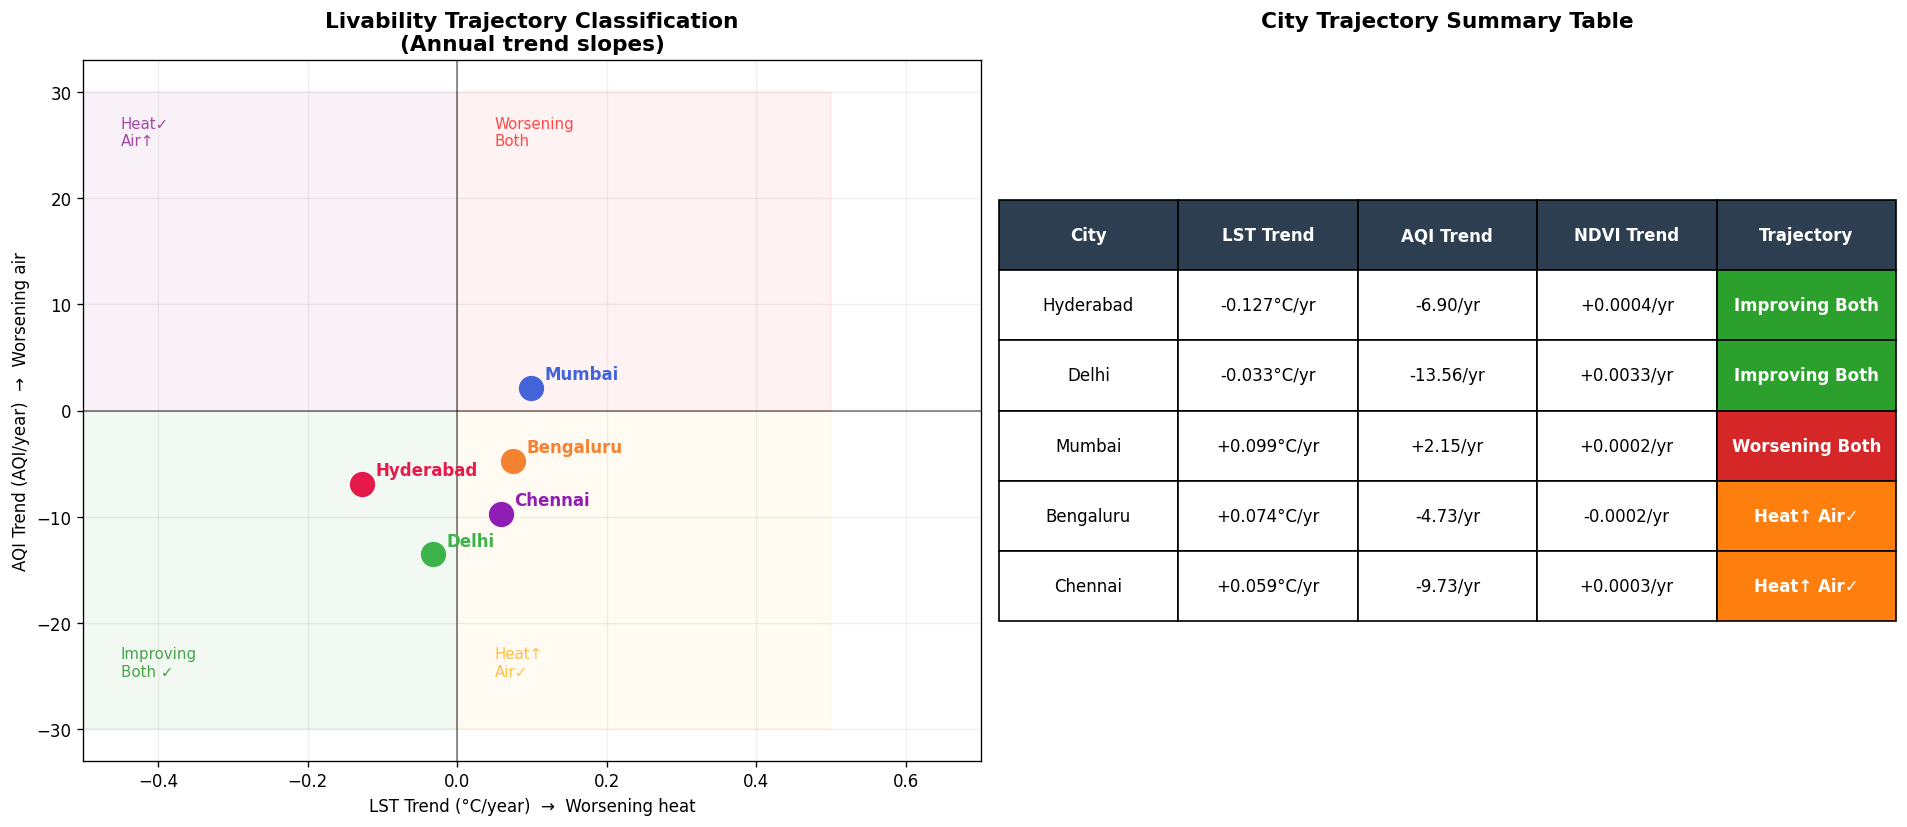


Livability Trajectory Classification:
  Hyderabad   : Improving Both       LST -0.127°C/yr | AQI -6.90/yr
  Delhi       : Improving Both       LST -0.033°C/yr | AQI -13.56/yr
  Mumbai      : Worsening Both       LST +0.099°C/yr | AQI +2.15/yr
  Bengaluru   : Heat↑ Air✓           LST +0.074°C/yr | AQI -4.73/yr
  Chennai     : Heat↑ Air✓           LST +0.059°C/yr | AQI -9.73/yr


In [ ]:

# Classify each city based on direction of LST and AQI trends
trajectory = {}

for city in cities:
    city_df = df[df['city'] == city].sort_values('year')
    aqi_city = city_df[city_df['AQI_mean'].notna()]

    # LST trend slope
    lst_slope, _, _, _, _ = stats.linregress(city_df['year'], city_df['LST_Celsius'])

    # AQI trend slope
    aqi_slope, _, _, _, _ = stats.linregress(aqi_city['year'], aqi_city['AQI_mean'])

    # NDVI trend slope
    ndvi_slope, _, _, _, _ = stats.linregress(city_df['year'], city_df['NDVI'])

    # Classify into quadrant
    if lst_slope <= 0 and aqi_slope <= 0:
        quadrant = 'Improving Both'
        q_color = '#2ca02c'
    elif lst_slope > 0 and aqi_slope > 0:
        quadrant = 'Worsening Both'
        q_color = '#d62728'
    elif lst_slope > 0 and aqi_slope <= 0:
        quadrant = 'Heat↑ Air✓'
        q_color = '#ff7f0e'
    else:
        quadrant = 'Heat✓ Air↑'
        q_color = '#9467bd'

    trajectory[city] = {
        'lst_slope': lst_slope,
        'aqi_slope': aqi_slope,
        'ndvi_slope': ndvi_slope,
        'quadrant': quadrant,
        'q_color': q_color
    }

traj_df = pd.DataFrame(trajectory).T

# Plot: 2x2 quadrant scatter
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ax1 = axes[0]
ax1.axhline(y=0, color='black', linewidth=1, alpha=0.5)
ax1.axvline(x=0, color='black', linewidth=1, alpha=0.5)

# Shade quadrants
ax1.fill_between([-0.5, 0], [0, 0], [30, 30], alpha=0.05, color='purple')
ax1.fill_between([0, 0.5], [0, 0], [30, 30], alpha=0.05, color='red')
ax1.fill_between([-0.5, 0], [-30, -30], [0, 0], alpha=0.05, color='green')
ax1.fill_between([0, 0.5], [-30, -30], [0, 0], alpha=0.05, color='orange')

# Add quadrant labels
ax1.text(-0.45, 25, 'Heat✓\nAir↑', fontsize=9, color='purple', alpha=0.7)
ax1.text(0.05, 25, 'Worsening\nBoth', fontsize=9, color='red', alpha=0.7)
ax1.text(-0.45, -25, 'Improving\nBoth ✓', fontsize=9, color='green', alpha=0.7)
ax1.text(0.05, -25, 'Heat↑\nAir✓', fontsize=9, color='orange', alpha=0.7)

for city, row in traj_df.iterrows():
    ax1.scatter(float(row['lst_slope']), float(row['aqi_slope']),
                color=colors[city], s=200, zorder=5)
    ax1.annotate(city, (float(row['lst_slope']), float(row['aqi_slope'])),
                 textcoords='offset points', xytext=(8, 5),
                 fontsize=10, fontweight='bold', color=colors[city])

ax1.set_title('Livability Trajectory Classification\n(Annual trend slopes)',
              fontsize=13, fontweight='bold')
ax1.set_xlabel('LST Trend (°C/year)  →  Worsening heat')
ax1.set_ylabel('AQI Trend (AQI/year)  →  Worsening air')
ax1.grid(True, alpha=0.2)
ax1.set_xlim(-0.5, 0.7)

# Plot 2: Summary table
ax2 = axes[1]
ax2.axis('off')
table_data = []
for city, row in traj_df.iterrows():
    table_data.append([
        city,
        f"{float(row['lst_slope']):+.3f}°C/yr",
        f"{float(row['aqi_slope']):+.2f}/yr",
        f"{float(row['ndvi_slope']):+.4f}/yr",
        row['quadrant']
    ])

table = ax2.table(
    cellText=table_data,
    colLabels=['City', 'LST Trend', 'AQI Trend', 'NDVI Trend', 'Trajectory'],
    cellLoc='center', loc='center',
    bbox=[0, 0.2, 1, 0.6]
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

# Color header
for j in range(5):
    table[0, j].set_facecolor('#2c3e50')
    table[0, j].set_text_props(color='white', fontweight='bold')

# Color trajectory cells
for i, (city, row) in enumerate(traj_df.iterrows()):
    table[i+1, 4].set_facecolor(row['q_color'])
    table[i+1, 4].set_text_props(color='white', fontweight='bold')

ax2.set_title('City Trajectory Summary Table', fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('trajectory_classification.png', bbox_inches='tight', dpi=150)
plt.show()

print("\nLivability Trajectory Classification:")
print("="*55)
for city, row in traj_df.iterrows():
    print(f"  {city:<12}: {row['quadrant']:<20} "
          f"LST {float(row['lst_slope']):+.3f}°C/yr | "
          f"AQI {float(row['aqi_slope']):+.2f}/yr")

decoupling analysis

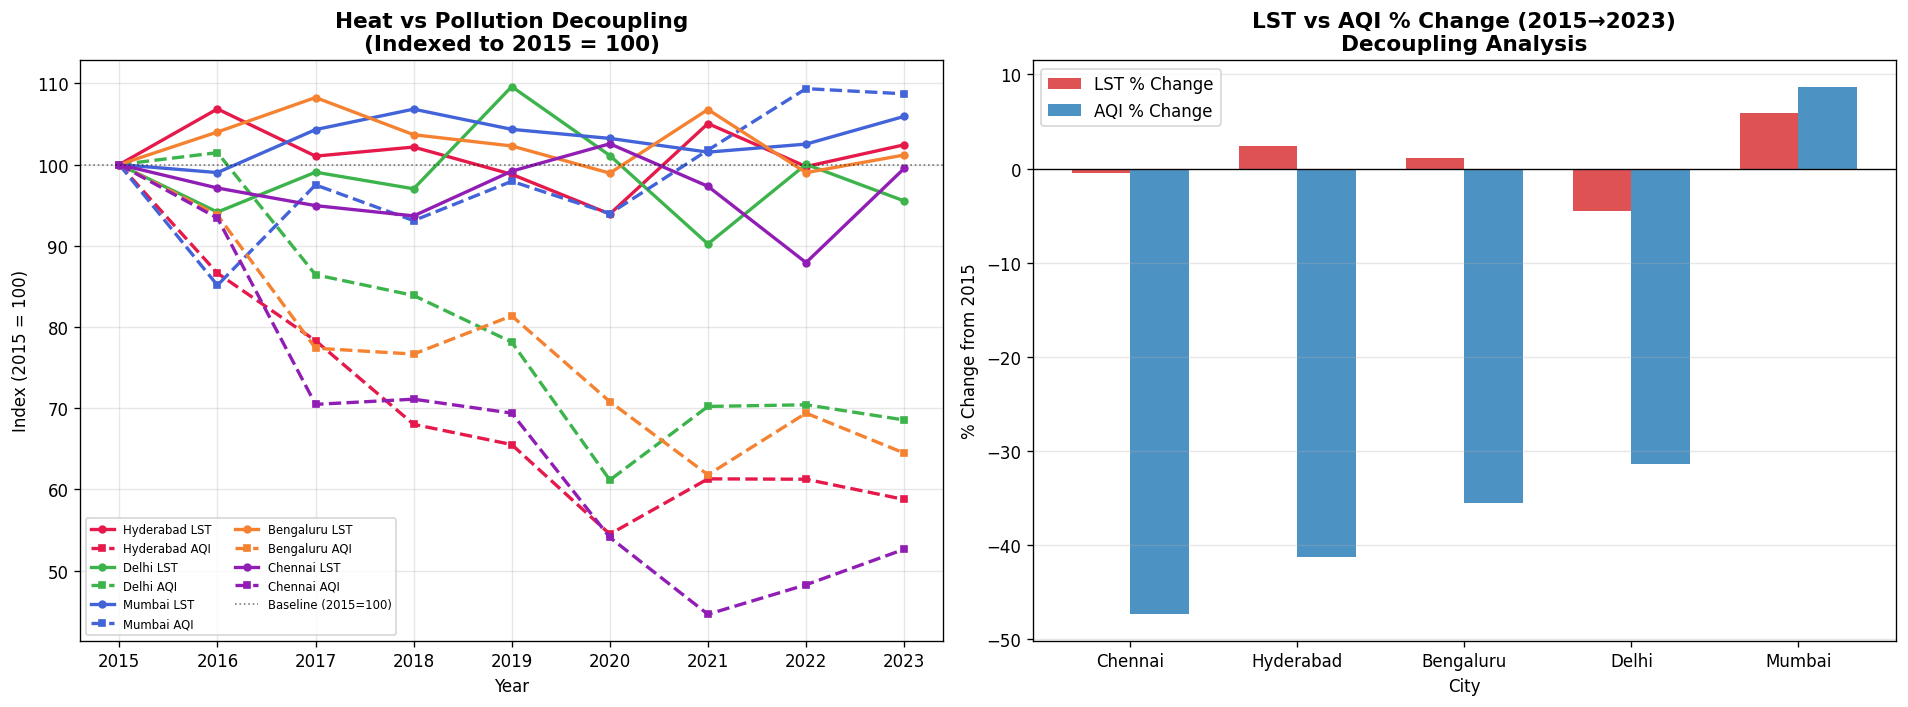


Heat-Pollution Decoupling Analysis (2015→2023):
City           LST Change   AQI Change   Decoupling
------------------------------------------------------------
Mumbai              +5.9%        +8.7%   ✗ Coupled
Delhi               -4.5%       -31.4%   ✓ Decoupled
Bengaluru           +1.2%       -35.5%   ✓ Decoupled
Hyderabad           +2.4%       -41.2%   ✓ Decoupled
Chennai             -0.5%       -47.4%   ✓ Decoupled


In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Normalize LST and AQI to base year 2015 = 100 (index)
# This shows relative change regardless of starting level
ax1 = axes[0]

aqi_df2 = df[df['AQI_mean'].notna()].copy()

for city in cities:
    city_df = aqi_df2[aqi_df2['city'] == city].sort_values('year')
    base_lst = city_df[city_df['year'] == 2015]['LST_Celsius'].values[0]
    base_aqi = city_df[city_df['year'] == 2015]['AQI_mean'].values[0]

    lst_idx = (city_df['LST_Celsius'] / base_lst) * 100
    aqi_idx = (city_df['AQI_mean'] / base_aqi) * 100

    ax1.plot(city_df['year'], lst_idx,
             color=colors[city], linewidth=2, linestyle='-',
             marker='o', markersize=4, label=f'{city} LST')
    ax1.plot(city_df['year'], aqi_idx,
             color=colors[city], linewidth=2, linestyle='--',
             marker='s', markersize=4, label=f'{city} AQI')

ax1.axhline(y=100, color='black', linewidth=1, linestyle=':', alpha=0.5, label='Baseline (2015=100)')
ax1.set_title('Heat vs Pollution Decoupling\n(Indexed to 2015 = 100)',
              fontsize=13, fontweight='bold')
ax1.set_xlabel('Year')
ax1.set_ylabel('Index (2015 = 100)')
ax1.legend(fontsize=7, ncol=2)
ax1.grid(True, alpha=0.3)
ax1.xaxis.set_major_locator(ticker.MultipleLocator(1))

# Plot 2: Decoupling gap (AQI improvement vs LST change)
ax2 = axes[1]
decoupling = {}
for city in cities:
    city_df = aqi_df2[aqi_df2['city'] == city].sort_values('year')
    base_lst = city_df[city_df['year'] == 2015]['LST_Celsius'].values[0]
    base_aqi = city_df[city_df['year'] == 2015]['AQI_mean'].values[0]
    last_lst = city_df.iloc[-1]['LST_Celsius']
    last_aqi = city_df.iloc[-1]['AQI_mean']

    lst_change_pct = ((last_lst - base_lst) / base_lst) * 100
    aqi_change_pct = ((last_aqi - base_aqi) / base_aqi) * 100

    # Decoupling score: AQI improved more than LST worsened = positive decoupling
    decoupling[city] = {
        'lst_change_pct': lst_change_pct,
        'aqi_change_pct': aqi_change_pct,
        'decoupling_gap': aqi_change_pct - lst_change_pct
    }

dec_df = pd.DataFrame(decoupling).T.sort_values('decoupling_gap')

x_pos = np.arange(len(dec_df))
width = 0.35
bars1 = ax2.bar(x_pos - width/2, dec_df['lst_change_pct'], width,
                label='LST % Change', color='#d62728', alpha=0.8)
bars2 = ax2.bar(x_pos + width/2, dec_df['aqi_change_pct'], width,
                label='AQI % Change', color='#1f77b4', alpha=0.8)

ax2.axhline(y=0, color='black', linewidth=0.8)
ax2.set_title('LST vs AQI % Change (2015→2023)\nDecoupling Analysis',
              fontsize=13, fontweight='bold')
ax2.set_xlabel('City')
ax2.set_ylabel('% Change from 2015')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(dec_df.index)
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('decoupling_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

print("\nHeat-Pollution Decoupling Analysis (2015→2023):")
print("="*60)
print(f"{'City':<12} {'LST Change':>12} {'AQI Change':>12} {'Decoupling':>12}")
print("-"*60)
for city, row in dec_df.sort_values('decoupling_gap', ascending=False).iterrows():
    direction = '✓ Decoupled' if row['aqi_change_pct'] < row['lst_change_pct'] else '✗ Coupled'
    print(f"{city:<12} {row['lst_change_pct']:>+11.1f}% {row['aqi_change_pct']:>+11.1f}% "
          f"  {direction}")

In [ ]:

from google.colab import files

# Save final enriched dataset with all scores
ranking_df.to_csv('master_with_scores.csv', index=False)

# Download all files
files.download('master_with_scores.csv')
files.download('lst_trends.png')
files.download('ndvi_trends.png')
files.download('aqi_trends.png')
files.download('correlation_analysis.png')
files.download('heat_sensitivity.png')
files.download('trajectory_classification.png')
files.download('decoupling_analysis.png')

print("All files downloaded successfully!")
print("\nFiles ready for Power BI:")
print("  - master_with_scores.csv  → main data source")
print("  - *.png files             → embed as visuals in dashboard")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All files downloaded successfully!

Files ready for Power BI:
  - master_with_scores.csv  → main data source
  - *.png files             → embed as visuals in dashboard
